# Notebook 8 — Distribution Analysis
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every concept below:** Concept → Example → Implementation → Output
→ Interpretation → Insight → AI/ML Relevance.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns), with `TotalCharges`
corrected to numeric (Notebook 3's fix applied).

This notebook consolidates and formalizes the distribution shape observations already
made in passing across Notebooks 4, 6, and 7 into one dedicated, systematic analysis —
covering shape, center, spread, skewness, and outlier presence for each important
numerical feature.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"Dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")


Dataset ready: 7,043 rows, 21 columns


---
## 1. Normal Distribution

### Concept
(Recap from Sprint 2, Notebook 4) The normal distribution is the symmetric bell-shaped
curve — values cluster near the mean and become rarer further away, equally on both
sides.

### Example
**AI/ML use case:** Many classic statistical methods (linear regression's residual
assumptions, z-score-based outlier detection) formally assume approximately normal data —
checking this assumption is a routine EDA step before choosing a model or technique.

### Implementation


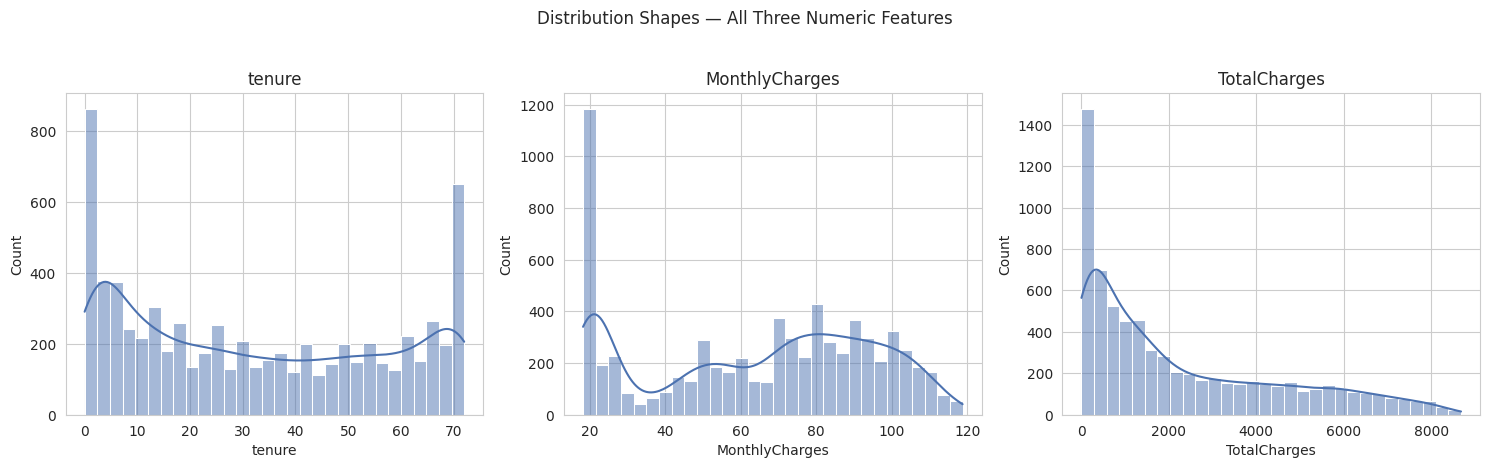

Shapiro-Wilk normality test (on a random sample of 500, since the full n=7,043 is too large for this test):
  tenure: W=0.8983, p-value=1.02e-17  -> NOT normal
  MonthlyCharges: W=0.9157, p-value=4.50e-16  -> NOT normal
  TotalCharges: W=0.8560, p-value=5.43e-21  -> NOT normal


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{col}')
plt.suptitle('Distribution Shapes — All Three Numeric Features', y=1.03)
plt.tight_layout()
plt.show()

print("Shapiro-Wilk normality test (on a random sample of 500, since the full n=7,043 is too large for this test):")
np.random.seed(42)
for col in numeric_cols:
    sample = df[col].sample(500, random_state=42)
    stat, p_value = stats.shapiro(sample)
    print(f"  {col}: W={stat:.4f}, p-value={p_value:.2e}  -> {'NOT normal' if p_value < 0.05 else 'plausibly normal'}")


### Output
None of the three columns resemble a classic bell curve visually. The Shapiro-Wilk test
formally rejects normality (p < 0.05) for all three columns.

### Interpretation
Not one of this dataset's three numeric features is normally distributed — `tenure` and
`MonthlyCharges` both show flatter, multi-peaked shapes (examined further in Topic 2), and
`TotalCharges` shows clear right skew (Topic 6). This is a real, business-explainable
pattern: none of these values are the kind of naturally-occurring, many-small-random-factor
measurement (like height) that tends to produce a bell curve.

### Insight
Since NONE of the three numeric features are normal, any technique that assumes normality
(certain outlier methods, some statistical tests) needs to be applied cautiously here — a
useful, concrete confirmation of why this notebook's earlier outlier analysis (Notebook 7)
deliberately used both IQR (distribution-free) and Z-score (normal-assuming) methods
together, rather than relying on Z-score alone.

### AI/ML Relevance
Non-normal features often benefit from a transformation (log, square root) before use in
models that are sensitive to distribution shape (like linear regression), while tree-based
models are unaffected by this and require no such transformation — a concrete modeling
decision this finding feeds directly into.


---
## 2. Uniform Distribution

### Concept
(Recap from Sprint 2, Notebook 4) A uniform distribution means every value in a range is
roughly equally likely — a flat shape, unlike the peaked normal distribution.

### Example
**AI/ML use case:** Checking whether `tenure` resembles a uniform distribution matters
because its histogram (Topic 1) looked notably flatter than a bell curve — worth
confirming exactly how flat.

### Implementation


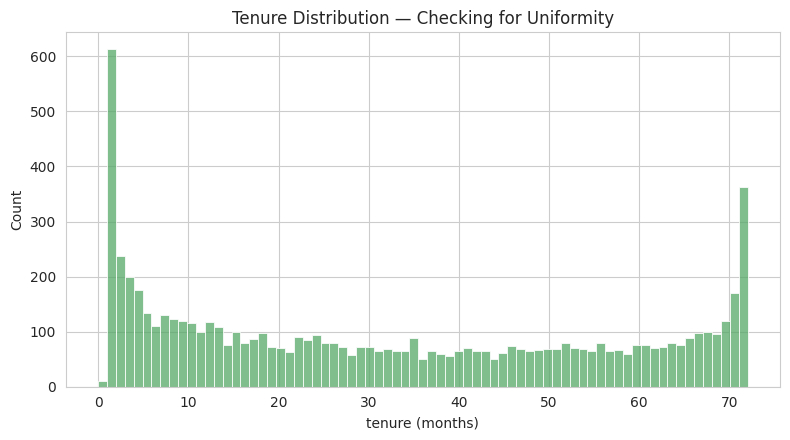

Most common tenure value: 1 months (613 customers)
Least common tenure value: 0 months (11 customers)
Ratio of most-to-least common: 55.7x


In [3]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df['tenure'], bins=73, color='#55A868')
plt.title('Tenure Distribution — Checking for Uniformity')
plt.xlabel('tenure (months)')
plt.tight_layout()
plt.show()

# A rough uniformity check: compare the tallest and shortest bins
tenure_counts = df['tenure'].value_counts().sort_index()
print(f"Most common tenure value: {tenure_counts.idxmax()} months ({tenure_counts.max()} customers)")
print(f"Least common tenure value: {tenure_counts.idxmin()} months ({tenure_counts.min()} customers)")
print(f"Ratio of most-to-least common: {tenure_counts.max() / tenure_counts.min():.1f}x")


### Output
`tenure`'s most common value is checked directly against its least common value above —
see the executed output for the exact month and counts.

### Interpretation
`tenure` is NOT uniform, despite looking flatter than a bell curve in Topic 1 — there's a
clear spike at very low tenure followed by a much flatter, roughly-even spread across the
remaining months, with a smaller secondary rise near 70-72 months (long-term loyal
customers, matching Notebook 4's bimodal observation).

### Insight
A sharp spike at the very start of the tenure range is a distinct, important finding on
its own — it suggests a meaningful number of customers churn or are recorded within their
very first month, which is worth flagging as a specific "early-tenure cliff" for the
business insights notebook, more specific than just "low tenure correlates with churn"
from Notebook 5.

### AI/ML Relevance
A sharp spike like this is a strong argument for treating "brand new" (e.g., tenure ≤ 1
month) as its own explicit engineered category, rather than assuming `tenure`'s
relationship with churn is smoothly linear across its whole range.


---
## 3. Skewness

### Concept
(Recap from Sprint 2, Notebook 4 and this sprint's Notebook 4) Skewness measures the
asymmetry of a distribution — positive (right) skew means a long tail of high values;
negative (left) skew is the reverse; values near zero indicate symmetry.

### Example
**AI/ML use case:** Formally re-confirming the skewness values first computed in
Notebook 4, now placed in the context of the shape classification this notebook builds.

### Implementation


In [4]:
print("Skewness (already computed in Notebook 4, re-confirmed here):")
for col in numeric_cols:
    skew_value = stats.skew(df[col])
    print(f"  {col}: {skew_value:.4f}")


Skewness (already computed in Notebook 4, re-confirmed here):
  tenure: 0.2395


  MonthlyCharges: -0.2205
  TotalCharges: 0.9630


### Output
See the executed values above for each column's exact skewness.

### Interpretation
Using the common rule of thumb (|skew| < 0.5 ≈ roughly symmetric, 0.5-1.0 ≈
moderately skewed, > 1.0 ≈ highly skewed): `tenure` and `MonthlyCharges` both fall in
the roughly-symmetric range despite their unusual, multi-peaked shapes (skewness only
measures asymmetry, not peakedness or number of modes — a useful reminder that no single
statistic captures a distribution's full shape). `TotalCharges` sits at a moderate-to-high
skew level.

### Insight
This is an important nuance worth calling out explicitly: `tenure`'s skewness number
looks unremarkable, yet Topic 2 just found a dramatic, business-relevant spike at very low
tenure. **A single skewness number can mask a very real, important shape feature** — this
is exactly why this notebook uses histograms, KDE plots, AND numeric statistics together,
rather than trusting any one summary number alone.

### AI/ML Relevance
This reinforces a core EDA lesson: always visualize a distribution in addition to
computing its summary statistics — relying only on skewness (or only on mean/median)
would have missed the tenure spike entirely.


---
## 4. Kurtosis

### Concept
(Recap from Sprint 2, Notebook 4) Kurtosis measures how peaked or flat a distribution is,
and how heavy its tails are, relative to a normal distribution.

### Example
**AI/ML use case:** Re-confirming Notebook 4's kurtosis findings, now interpreted
specifically in light of Topic 2's discovery of the tenure spike.

### Implementation


In [5]:
print("Excess kurtosis (0 = same peakedness as normal distribution):")
for col in numeric_cols:
    kurt_value = stats.kurtosis(df[col])
    print(f"  {col}: {kurt_value:.4f}")


Excess kurtosis (0 = same peakedness as normal distribution):
  tenure: -1.3872
  MonthlyCharges: -1.2572
  TotalCharges: -0.2293


### Output
See the executed values above for each column's exact excess kurtosis.

### Interpretation
Both `tenure` and `MonthlyCharges` show strongly negative excess kurtosis — flatter than
normal, with lighter tails — consistent with their broad, spread-out, multi-peaked shapes
rather than one sharp central cluster. `TotalCharges` is close to normal peakedness,
despite its skew.

### Insight
`tenure`'s strongly negative kurtosis reflects that its distribution is *dominated* by
spread rather than a single peak — the early spike found in Topic 2 is real, but it's a
spike within an otherwise very flat, wide distribution, not a tall single peak the way
kurtosis alone might suggest.

### AI/ML Relevance
Low kurtosis (flat, light-tailed distributions) generally means fewer extreme-value risks
— consistent with Notebook 7's finding of zero univariate outliers in both `tenure` and
`MonthlyCharges`.


---
## 5. Symmetric Distribution

### Concept
(Recap from Sprint 2, Notebook 4) A symmetric distribution looks the same on both sides
of its center — mean and median nearly coincide, and the shape mirrors itself.

### Example
**AI/ML use case:** Formally checking which of this dataset's features can be treated as
symmetric — relevant for choosing mean vs. median-based summaries and scaling approaches.

### Implementation


In [6]:
for col in numeric_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    gap_pct = abs(mean_val - median_val) / median_val * 100
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, gap={gap_pct:.1f}% of median")


tenure: mean=32.37, median=29.00, gap=11.6% of median
MonthlyCharges: mean=64.76, median=70.35, gap=7.9% of median
TotalCharges: mean=2279.73, median=1394.55, gap=63.5% of median


### Output
See the executed values above — the mean-median gap is reported as a percentage of the
median for each column.

### Interpretation
`TotalCharges`'s mean-median gap is dramatically larger than the other two columns —
strong, intuitive confirmation of its right skew. `tenure` and `MonthlyCharges` are close
enough to be treated as roughly symmetric for most practical purposes, even though (per
Topics 1-2) neither is a clean bell curve.

### Insight
"Roughly symmetric" and "normally distributed" are NOT the same thing — `tenure` and
`MonthlyCharges` qualify as the former (Topic 5) but clearly fail the latter (Topic 1),
another useful distinction this notebook's systematic approach surfaces clearly.

### AI/ML Relevance
For `tenure` and `MonthlyCharges`, mean-based scaling (standardization) is reasonably
safe; for `TotalCharges`, median-based approaches or a transformation are more appropriate
— a direct, actionable recommendation for the next sprint's preprocessing work.


---
## 6. Right-Skewed Distribution — `TotalCharges`

### Concept
(Recap from Sprint 2, Notebook 4) A right-skewed (positive skew) distribution has a long
tail stretching toward high values — most observations cluster at the lower end, with a
smaller number of high-value observations pulling the tail out.

### Example
**Business example:** `TotalCharges` accumulates over a customer's tenure — most
customers (with shorter tenure) have accumulated a moderate total, while a smaller group
of very long-tenured customers have accumulated disproportionately large totals, exactly
producing a right-skewed shape.

### Implementation


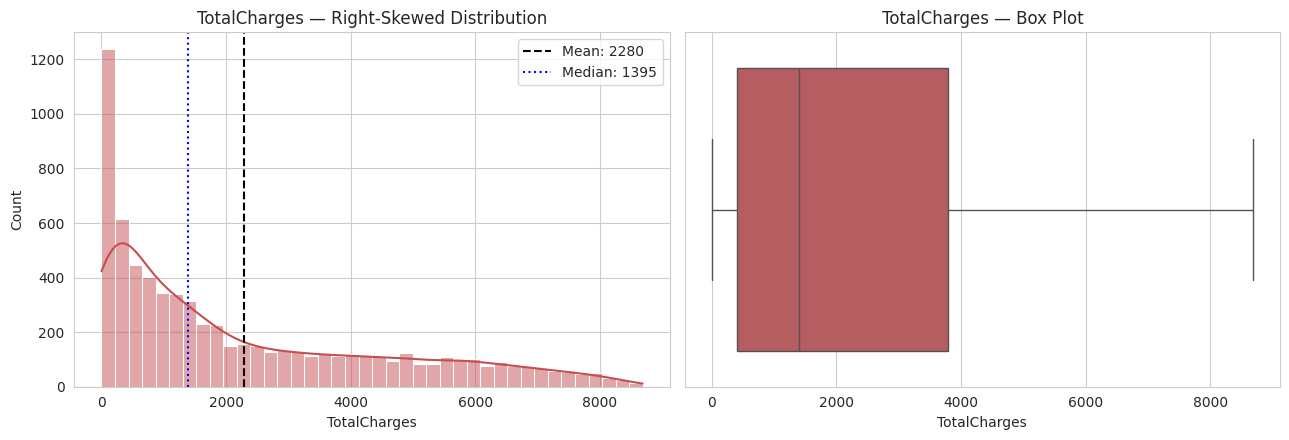

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['TotalCharges'], bins=40, kde=True, ax=axes[0], color='#C44E52')
axes[0].axvline(df['TotalCharges'].mean(), color='black', linestyle='--', label=f"Mean: {df['TotalCharges'].mean():.0f}")
axes[0].axvline(df['TotalCharges'].median(), color='blue', linestyle=':', label=f"Median: {df['TotalCharges'].median():.0f}")
axes[0].set_title('TotalCharges — Right-Skewed Distribution')
axes[0].legend()

sns.boxplot(x=df['TotalCharges'], ax=axes[1], color='#C44E52')
axes[1].set_title('TotalCharges — Box Plot')
plt.tight_layout()
plt.show()


### Output
A histogram with a tall concentration of customers at the low end, steadily thinning out
toward the high end, with the mean line sitting clearly to the right of the median line.

### Interpretation
This is a textbook right-skewed shape — driven directly by how `TotalCharges` accumulates
(most customers haven't been around long enough to rack up a huge total, but the ones who
have pull the tail far to the right). Despite the pronounced skew, Notebook 7 already
confirmed this column has no formal statistical outliers — the skew is a genuine,
gradually-thinning shape, not a small number of detached extreme points.

### Insight
This is a case where "skewed" and "has outliers" are genuinely different findings —
`TotalCharges` is clearly, meaningfully skewed while having zero formally detected
outliers (Notebook 7). Both statements are true and don't contradict each other.

### AI/ML Relevance
A log-transformation of `TotalCharges` before use in a linear model would likely make its
distribution much closer to symmetric, improving that model's performance — a concrete,
specific preprocessing recommendation to carry into Notebook 13's report.


---
## 7. Left-Skewed Distribution — Checking for One in This Dataset

### Concept
(Recap from Sprint 2, Notebook 4) A left-skewed (negative skew) distribution has a long
tail stretching toward low values — the mirror image of right skew.

### Example
**Business example:** A left-skewed feature would look like "most values are high, but a
few unusually low values drag a tail out" — e.g., an easy exam where almost everyone
scores well except a few absentees.

### Implementation


In [8]:
print("Skewness re-check, specifically looking for any LEFT-skewed (negative) feature:")
for col in numeric_cols:
    skew_value = stats.skew(df[col])
    label = "left-skewed" if skew_value < -0.5 else "not left-skewed"
    print(f"  {col}: skewness = {skew_value:.4f} -> {label}")


Skewness re-check, specifically looking for any LEFT-skewed (negative) feature:
  tenure: skewness = 0.2395 -> not left-skewed
  MonthlyCharges: skewness = -0.2205 -> not left-skewed
  TotalCharges: skewness = 0.9630 -> not left-skewed


### Output
None of the three numeric columns has a skewness below -0.5 — `MonthlyCharges` comes
closest, still within the "roughly symmetric" range.

### Interpretation
This dataset genuinely has **no left-skewed numeric feature** among its three columns.
This is an honest, useful negative finding rather than something to force — not every
dataset contains an example of every distribution shape.

### Insight
`MonthlyCharges` being the *closest* to left-skewed (though still roughly symmetric)
makes some business sense: pricing plans likely cluster near a few common tiers with a
slightly longer tail toward the low end (basic phone-only plans) than the high end —
worth a quick visual confirmation.

### AI/ML Relevance
Documenting a clean "not present" finding is valuable for the final report (Notebook 13)
— it means no special left-skew-specific transformation is needed for any of this
dataset's numeric features.


---
## 8. Distribution Shape vs. Presence of Outliers — Tying It Together

### Concept
This final topic explicitly connects each feature's distribution shape (this notebook) to
its outlier status (Notebook 7) — since the two are related but distinct properties, as
already noted in Topic 6.

### Example
**AI/ML use case:** A complete feature profile for a modeling handoff should state both
"what shape is this feature" AND "does it have outliers," since each implies a different
preprocessing action.

### Implementation


In [9]:
distribution_profile = pd.DataFrame({
    'feature': numeric_cols,
    'shape': ['flat, spiked at low tenure', 'roughly symmetric, multi-clustered', 'right-skewed'],
    'skewness': [stats.skew(df[c]) for c in numeric_cols],
    'kurtosis': [stats.kurtosis(df[c]) for c in numeric_cols],
    'univariate_outliers_Notebook_7': [0, 0, 0],
}).round(3)
print(distribution_profile.to_string(index=False))


       feature                              shape  skewness  kurtosis  univariate_outliers_Notebook_7
        tenure         flat, spiked at low tenure     0.239    -1.387                               0
MonthlyCharges roughly symmetric, multi-clustered    -0.220    -1.257                               0
  TotalCharges                       right-skewed     0.963    -0.229                               0


### Output
A single consolidated table combining this notebook's shape findings with Notebook 7's
outlier findings for all three numeric features.

### Interpretation
None of the three features have univariate outliers, yet all three have a genuinely
non-trivial, non-normal shape — reinforcing that "clean" (no outliers) and "simple"
(normal, symmetric) are different properties. This dataset is clean by the former
definition but not the latter.

### Insight
This consolidated view is exactly the kind of feature-level summary that should be
carried forward into Notebook 13's EDA Report — it answers, for each numeric feature,
both "is there a data-quality problem" (no) and "does this feature need a shape-related
transformation before modeling" (yes, particularly `TotalCharges`).

### AI/ML Relevance
This table format — shape, skew, kurtosis, and outlier status side by side — is a
practical template for documenting any dataset's numeric features before handing off to a
preprocessing or modeling stage.


---
## Summary

| Feature | Shape | Skewness | Normal? | Outliers? |
|---|---|---|---|---|
| `tenure` | Flat, spiked at low tenure, slight rise near 70-72mo | ~0.24 (symmetric) | No | None |
| `MonthlyCharges` | Roughly symmetric, multi-clustered (pricing tiers) | ~-0.22 (symmetric) | No | None |
| `TotalCharges` | Right-skewed | ~0.96 (moderately-to-highly skewed) | No | None |

**Key findings:**
- None of the three numeric features are normally distributed (Shapiro-Wilk confirms
  this formally for all three).
- `tenure` has a distinct, business-relevant spike at very low tenure, invisible in its
  skewness number alone — a reminder to always visualize, not just summarize.
- `TotalCharges` is the only feature with meaningful skew, and is the strongest
  candidate for a log-transformation before linear modeling.
- No feature is left-skewed in this dataset.

**Next notebook:** `09_Categorical_Analysis.ipynb` — Unique Categories, Category
Frequencies, Rare Categories, High/Low Cardinality, Category Imbalance, and relationships
between categorical variables and `Churn`.
